In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from sklearn.model_selection import train_test_split

from config import SEED

## Carga de datos

In [2]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

In [3]:
dataset = 'aug_cuadrados'

## Imagenes

In [4]:
train_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/train'
val_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/val'
test_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/test'

In [5]:
X_train, y_train = load_image_dataset(train_dir, target_size=(224, 224))
X_val, y_val = load_image_dataset(val_dir, target_size=(224, 224))
X_test, y_test = load_image_dataset(test_dir, target_size=(224, 224))

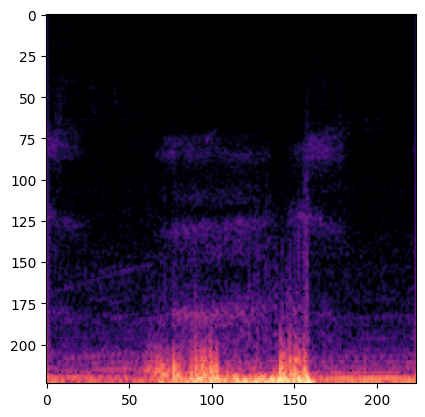

In [6]:
plt.imshow(X_train[2]);

In [7]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(224, 224, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

In [8]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 224, 224, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# lr_schedule = keras.optimizers.schedules.PolynomialDecay(
#     initial_learning_rate=1e-3,
#     decay_steps=3000,
#     end_learning_rate=1e-7,
#     power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 274s 671ms/step - auc: 0.5276 - loss: 0.7020 - recall: 0.6141 - val_auc: 0.5709 - val_loss: 0.6883 - val_recall: 0.9339
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 286s 715ms/step - auc: 0.5492 - loss: 0.6876 - recall: 0.7251 - val_auc: 0.5713 - val_loss: 0.6891 - val_recall: 0.9903
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 280s 700ms/step - auc: 0.5719 - loss: 0.6834 - recall: 0.7072 - val_auc: 0.5852 - val_loss: 0.6858 - val_recall: 0.9369
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 280s 700ms/step - auc: 0.5839 - loss: 0.6787 - recall: 0.7418 - val_auc: 0.6007 - val_loss: 0.6773 - val_recall: 0.6996
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 336s 736ms/step - auc: 0.5857 - loss: 0.6780 - recall: 0.6877 - val_auc: 0.6004 - val_loss: 0.6767 - val_recall: 0.8617
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 267s 669ms/step - auc: 0.5971 - loss: 0.6747 - recall: 0.7224 - val_auc: 0.5883 - val_loss: 0.6781 - val_recall: 0.6796
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 

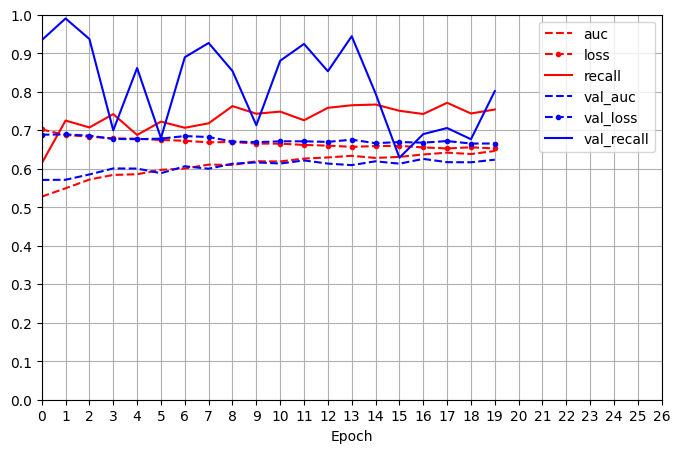

In [12]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 26], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 27), yticks=np.arange(0, 1.1, 0.1))
plt.show()

In [13]:
model.evaluate(X_test, y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 633ms/step - auc: 0.6141 - loss: 0.6739 - recall: 0.7631


[0.6738880276679993, 0.6140800714492798, 0.7631068229675293]

In [14]:
os.makedirs(f'./neural_network/modelos/ventanas/{dataset}', exist_ok=True)

model.save(f'./neural_network/modelos/ventanas/{dataset}/imagenes.keras')

## Arrays

In [4]:
train_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)

In [6]:
X_train = X_train.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

In [7]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

In [8]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

In [9]:
model_melspec.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 224, 224, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [11]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [12]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 353s 860ms/step - auc: 0.5141 - loss: 0.7100 - recall: 0.6054 - val_auc: 0.5695 - val_loss: 0.6931 - val_recall: 0.9912
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 351s 783ms/step - auc: 0.5380 - loss: 0.6901 - recall: 0.6928 - val_auc: 0.5804 - val_loss: 0.6826 - val_recall: 0.8211
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 287s 719ms/step - auc: 0.5594 - loss: 0.6861 - recall: 0.7069 - val_auc: 0.5767 - val_loss: 0.6861 - val_recall: 0.9404
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 280s 701ms/step - auc: 0.5652 - loss: 0.6849 - recall: 0.7364 - val_auc: 0.5891 - val_loss: 0.6810 - val_recall: 0.6453
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 280s 701ms/step - auc: 0.5844 - loss: 0.6794 - recall: 0.6480 - val_auc: 0.5950 - val_loss: 0.6789 - val_recall: 0.8782
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 279s 697ms/step - auc: 0.5773 - loss: 0.6802 - recall: 0.7113 - val_auc: 0.5908 - val_loss: 0.6785 - val_recall: 0.5348
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 

In [13]:
model_melspec.evaluate(X_test, y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 78s 625ms/step - auc: 0.6039 - loss: 0.6712 - recall: 0.7252


[0.6712464094161987, 0.6038998961448669, 0.7252427339553833]

In [14]:
model_melspec.save(f'./neural_network/modelos/ventanas/{dataset}/melspec.keras')